In [56]:
import os 
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [57]:
def preprocess_image(img):

    # Resize Image
    resized = cv2.resize(img, (64, 64))

    # Convert to Gray
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Blur Image
    blurred = cv2.GaussianBlur(gray, (5,5), 0)

    # Edge Detection
    edges = cv2.Canny(blurred, 100, 200)

    # Thresholding
    _, threshold = cv2.threshold(
        gray,
        120,
        255,
        cv2.THRESH_BINARY
    )

    # Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # Return Processed Images
    return resized, gray, blurred, edges, threshold, equalized


In [58]:
# FUNCTION : DATA AUGMENTATION
# =====================================================

def augment_image(gray):

    # Flip Image
    flipped = cv2.flip(gray, 1)

    # Invert Image
    inverted = cv2.bitwise_not(gray)

    # Zoom Image
    zoom = gray[10:54, 10:54]
    zoom = cv2.resize(zoom, (64,64))

    # Rotate Image
    matrix = cv2.getRotationMatrix2D((32,32), 20, 1)

    rotated = cv2.warpAffine(
        gray,
        matrix,
        (64,64)
    )

    # Return Augmented Images
    return flipped, inverted, zoom, rotated



Class :  apple


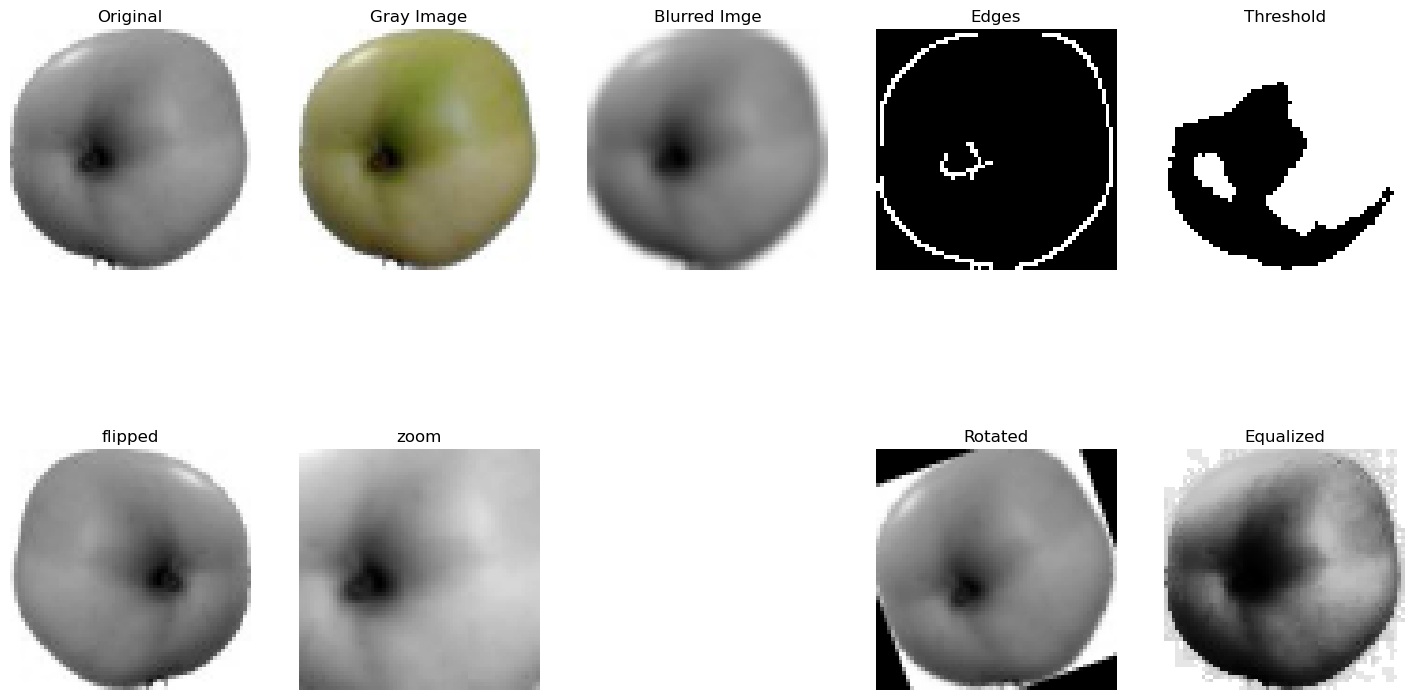

Class :  tomato


In [59]:
    data=[]
    labels=[]
    classes = ["apple","tomato"]
    count=0

    # loading data 

    for label , cls in enumerate(classes):
        folder  = f"dataset/Train/{cls}"
    
        print("Class : ", cls)
    
        for file in os.listdir(folder):
            path = os.path.join(folder,file)
    
            # read image 
            img=cv2.imread(path)
    
            # broken img 
            if img is None:
                continue
    
            # calling processing function 
    
            resized, gray , blurred, edges , threshold, equalized= preprocess_image(img)
    
            # calling augmentation function 
            flipped, inverted, zoom , rotated=augment_image(gray)

            processed_images = [
                gray,
                flipped,
                inverted,
                zoom,
                rotated,
                edges,
                threshold,
                equalized
            ]

            for image in processed_images:
        
                data.append(image.flatten())
                labels.append(label)

        # show image
            if count < 1:

                plt.figure(figsize=(18,10))
                    #original image 
                plt.subplot(2,5,1)
                plt.imshow(gray, cmap="gray")
                plt.title("Original")
                plt.axis("off")
        
                #gray image            
                plt.subplot(2,5,2)
                plt.imshow(cv2.cvtColor(resized,cv2.COLOR_BGR2RGB))
                plt.title("Gray Image")
                plt.axis("off")
                #blurred image
                plt.subplot(2,5,3)
                plt.imshow(blurred,cmap="gray")
                plt.title("Blurred Imge")
                plt.axis("off")
        
                #Edges
                plt.subplot(2,5,4)
                plt.imshow(edges, cmap="gray")
                plt.title("Edges")
                plt.axis("off")
                
                # Threshold   
                plt.subplot(2,5,5)
                plt.imshow(threshold, cmap="gray")
                plt.title("Threshold")
                plt.axis("off")
        
                #Flipped 
                plt.subplot(2,5,6)
                plt.imshow(flipped,cmap="gray")
                plt.title("flipped")
                plt.axis("off")
                # zoom 
                plt.subplot(2,5,7)
                plt.imshow(zoom, cmap="gray")
                plt.title("zoom")
                plt.axis("off")
        
                # Rotated
                plt.subplot(2,5,9)
                plt.imshow(rotated, cmap="gray")
                plt.title("Rotated")
                plt.axis("off")
        
                # Equalized
                plt.subplot(2,5,10)
                plt.imshow(equalized, cmap="gray")
                plt.title("Equalized")
                plt.axis("off")
                plt.show()

            count+=1
        

        

                   
        

In [60]:
# CONVERT TO NUMPY ARRAY
# =====================================================

X = np.array(data)
y = np.array(labels)

print("\nDataset Loaded Successfully")
print("Total Images :", len(X))


Dataset Loaded Successfully
Total Images : 11256


In [61]:
# SPLIT DATASET
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
  
    random_state=42
)

print("\nTraining Images :", len(X_train))
print("Testing Images :", len(X_test))


Training Images : 9004
Testing Images : 2252


In [62]:
# CREATE MODELS
# =====================================================

models = DecisionTreeClassifier()



In [63]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [66]:
# ==========================================
# PREDICTION
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# MODEL EVALUATION
# ==========================================

print("\n===== RESULT =====")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy :", accuracy)

# Confusion Matrix
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred, labels=[0,1]))

# Classification Report
print("\nClassification Report :")

print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=["Apple", "Tomato"],
    zero_division=0
))


===== RESULT =====

Accuracy : 0.7477797513321492

Confusion Matrix :
[[694 430]
 [138 990]]

Classification Report :
              precision    recall  f1-score   support

       Apple       0.83      0.62      0.71      1124
      Tomato       0.70      0.88      0.78      1128

    accuracy                           0.75      2252
   macro avg       0.77      0.75      0.74      2252
weighted avg       0.77      0.75      0.74      2252




Showing Prediction Result...



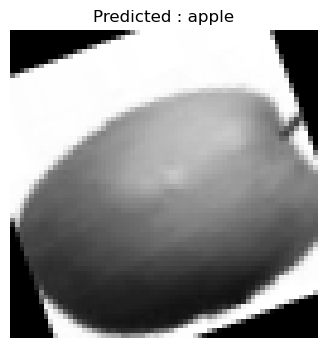

In [67]:
# SHOW TEST RESULT
# ==========================================

print("\nShowing Prediction Result...\n")

plt.figure(figsize=(4,4))

plt.imshow(X_test[0].reshape(64,64), cmap="gray")

predicted_label = classes[y_pred[0]]

plt.title(f"Predicted : {predicted_label}")

plt.axis("off")

plt.show()